# LF 05 · Field luminosity function (Blanton et al. 2005)

Reads the r-band field luminosity function of Blanton et al. (2005, Table 2), converts it to the H0 = 70 magnitude scale used in this work, and saves it for the multi-cluster comparison.

**Input**
- `DATA/Blanton2005_Table2.csv` – Table 2 of Blanton et al. (2005): Φ(M_r − 5 log h) with errors, as text such as "(21.35 ± 8.94) × 10⁻²"

**Output**
- `Field_LF.csv` – M_r, Φ, Φ_err in h³ Mpc⁻³ mag⁻¹

In [1]:
# ============================================================================
# Setup
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import astropy.units as u
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',

    # Ticks: inwards, on all four sides, with minor ticks
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,

    # Axes and lines
    'lines.linewidth': 2,
    'axes.linewidth': 3.5,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

In [2]:
import re

def unicode_superscript_to_ascii(s):
    """Convert unicode superscripts (e.g. ⁻²) to ASCII."""
    return s.translate(str.maketrans('⁰¹²³⁴⁵⁶⁷⁸⁹⁻', '0123456789-'))

def parse_value_and_error(s):
    """
    Parse a table entry such as "(21.35 ± 8.94) × 10⁻²" into (value, error).
    Returns (nan, nan) if the string does not match.
    """
    s = unicode_superscript_to_ascii(
        s.replace('×', 'x').replace('±', '+-').replace('−', '-').replace('–', '-')
    )
    pattern = r'\(([\d\.]+)\s*\+\-\s*([\d\.]+)\)\s*x\s*10([-\d]+)'
    m = re.match(pattern, s.strip())
    if m:
        val, err, exp = float(m[1]), float(m[2]), int(m[3])
        factor = 10 ** exp
        return val * factor, err * factor
    return np.nan, np.nan

# Blanton et al. (2005) Table 2, r band
df = pd.read_csv("../../DATA/Blanton2005_Table2.csv")

# Total LF and its error, from the text column
df[['phi_total', 'phi_total_err']] = df['Φ(Mr - 5 log h) Total'].apply(
    lambda x: pd.Series(parse_value_and_error(x))
)
df['Mr - 5 log h'] = df['Mr - 5 log h'].astype(float)

# Double-Schechter parameters of Blanton et al. (2005), r band
params_r_band = {
    "Total":     {"M_star": -20.04, "phi_star_1": 1.56e-2, "alpha_1": -0.17, "phi_star_2": 0.62e-2, "alpha_2": -1.52},
    "Corrected": {"M_star": -19.99, "phi_star_1": 1.34e-2, "alpha_1":  0.03, "phi_star_2": 0.86e-2, "alpha_2": -1.40},
    "Raw":       {"M_star": -20.01, "phi_star_1": 1.26e-2, "alpha_1":  0.01, "phi_star_2": 0.86e-2, "alpha_2": -1.34},
}

def phi_M(M, M_star, phi_star_1, alpha_1, phi_star_2, alpha_2):
    """
    Double Schechter function in magnitudes:
        Phi(M) = 0.4 ln(10) exp[-10^{-0.4(M-M*)}]
                 * [phi*_1 10^{-0.4(M-M*)(alpha_1+1)} + phi*_2 10^{-0.4(M-M*)(alpha_2+1)}]
    """
    ln10 = np.log(10)
    x = M - M_star
    exp_term = np.exp(-10 ** (-0.4 * x))
    schechter1 = phi_star_1 * 10 ** (-0.4 * x * (alpha_1 + 1))
    schechter2 = phi_star_2 * 10 ** (-0.4 * x * (alpha_2 + 1))
    return 0.4 * ln10 * exp_term * (schechter1 + schechter2)

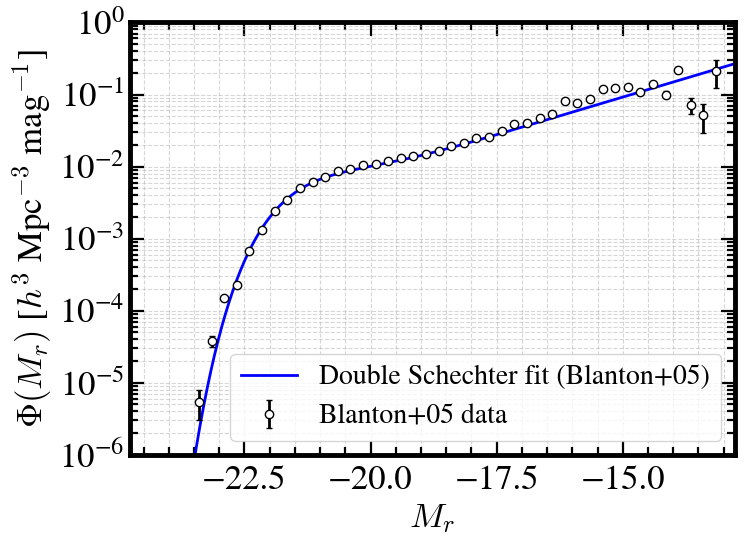

In [3]:
# Blanton et al. (2005) quote M_r - 5 log h; convert to M_r for h = 0.7
h = cosmo.H0.value / 100.0
mr_offset = 5 * np.log10(h)

M_r_grid = np.linspace(-24, -12, 500) + mr_offset     # model grid
Mr_obs = df['Mr - 5 log h'] + mr_offset               # table points

fig, ax = plt.subplots(figsize=(8, 6))

# Double-Schechter fit ("Total")
params = params_r_band["Total"]
model_phi = phi_M(
    M_r_grid,
    M_star=params["M_star"] + mr_offset,
    phi_star_1=params["phi_star_1"],
    alpha_1=params["alpha_1"],
    phi_star_2=params["phi_star_2"],
    alpha_2=params["alpha_2"]
)
ax.plot(M_r_grid, model_phi, color='blue', label='Double Schechter fit (Blanton+05)')

# Table points
ax.errorbar(
    Mr_obs, df['phi_total'], yerr=df['phi_total_err'],
    fmt='o', markersize=6, capsize=2, mfc='white', mec='black', ecolor='black',
    linestyle='none', label='Blanton+05 data'
)

ax.set_yscale('log')
ax.set_xlim(M_r_grid.min(), M_r_grid.max())
ax.set_ylim(1e-6, 1)
ax.set_xlabel(r'$M_r$')
ax.set_ylabel(r'$\Phi(M_r)$ [$h^3$ Mpc$^{-3}$ mag$^{-1}$]')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(fontsize=20)

plt.tight_layout()
plt.show()

# Save every table point (the cut at M_r < 0 keeps all rows)
mask = Mr_obs < -0
df_save = pd.DataFrame({
    'M_r': Mr_obs[mask],
    'Phi': df['phi_total'][mask],
    'Phi_err': df['phi_total_err'][mask]
})
df_save.to_csv('Field_LF.csv', index=False)